# Banking Risk Analysis Dashboard

## Business Intelligence Project

### Tools
- Python
- SQL
- Power BI
- Excel
- Pandas
- Matplotlib
- Seaborn

---

## Executive Summary

This project analyzes customer banking data to identify the characteristics associated with personal loan acceptance. Using exploratory data analysis and business intelligence techniques, the project uncovers trends in customer demographics, income, mortgage holdings, and banking product usage. The insights are intended to support data-driven marketing, customer segmentation, and lending strategies.

In [3]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [4]:
# Load the dataset

df = pd.read_csv("Bank_Personal_Loan_Modelling(1).csv")

# Display the first five rows
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1/60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1/50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1/00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2/70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1/00,2,0,0,0,0,0,1


In [5]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 5000
Columns: 14


# Data Understanding

Before performing any analysis, we first examine the structure of the dataset to understand the available variables, their data types, and whether there are any missing values or inconsistencies.

This helps determine the appropriate preprocessing steps and identify variables that may be useful for business insights.

In [6]:
df.dtypes
df.isnull().sum()
print("Duplicate rows:", df.duplicated().sum())
df["CCAvg"].head(10)

Duplicate rows: 0


0    1/60
1    1/50
2    1/00
3    2/70
4    1/00
5    0/40
6    1/50
7    0/30
8    0/60
9    8/90
Name: CCAvg, dtype: str

# Data Cleaning

The initial data quality assessment identified that the **CCAvg** (average monthly credit card spending) variable was stored as text because decimal values used a forward slash (`/`) instead of a decimal point (`.`).

To prepare the data for analysis, the values were converted to a numeric format by replacing the separator and casting the column to a floating-point data type.

No duplicate records were found in the dataset.

In [7]:
# Replace "/" with "." and convert to float

df["CCAvg"] = (
    df["CCAvg"]
    .str.replace("/", ".", regex=False)
    .astype(float)
)

# Check the result
df["CCAvg"].head(10)

0    1.6
1    1.5
2    1.0
3    2.7
4    1.0
5    0.4
6    1.5
7    0.3
8    0.6
9    8.9
Name: CCAvg, dtype: float64

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps uncover patterns, relationships, and trends within the banking customer data before creating dashboards or predictive models.

We begin by examining the distribution of customer ages.

# Chart 1: Customer Age Distribution

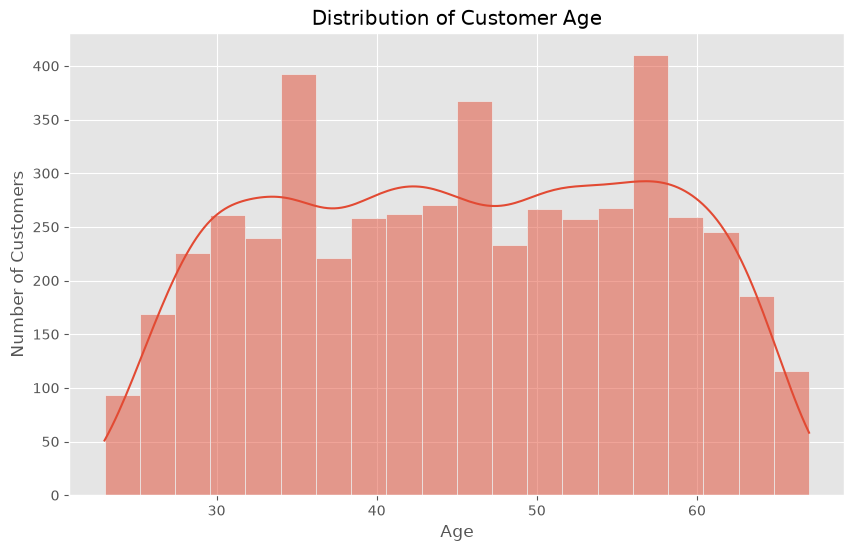

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True
)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

### Interpretation

The age distribution illustrates the spread of customers across different age groups.

Understanding customer age helps identify the dominant demographic served by the bank and supports targeted marketing strategies.

# Chart 2: Income Distribution

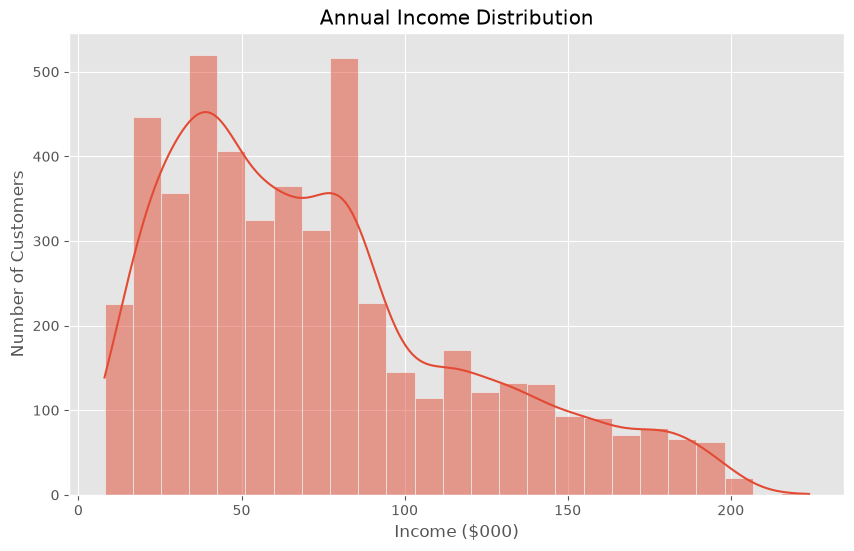

In [9]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Income",
    bins=25,
    kde=True
)

plt.title("Annual Income Distribution")
plt.xlabel("Income ($000)")
plt.ylabel("Number of Customers")

plt.show()

### Interpretation

Annual income is an important indicator of a customer's financial capacity.

This distribution highlights the range of customer incomes and helps identify high-income segments that may be more likely to accept financial products such as personal loans.

# Chart 3: Personal Loan Acceptance

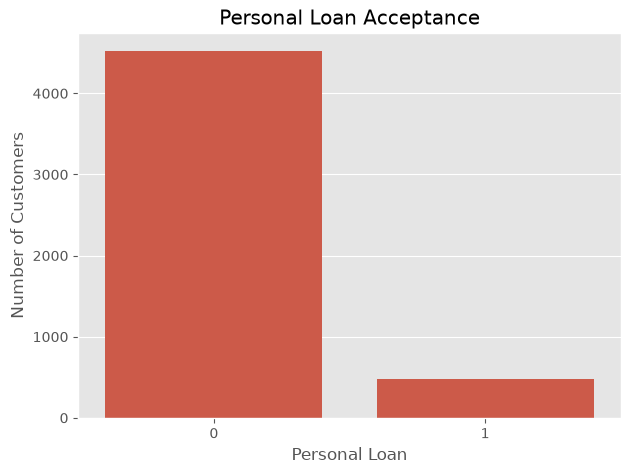

In [10]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Personal Loan"
)

plt.title("Personal Loan Acceptance")
plt.xlabel("Personal Loan")
plt.ylabel("Number of Customers")

plt.show()

### Interpretation

This chart compares customers who accepted a personal loan against those who did not.

The distribution helps assess class balance and provides an initial understanding of loan uptake within the customer base.

# Chart 4: Education Levels

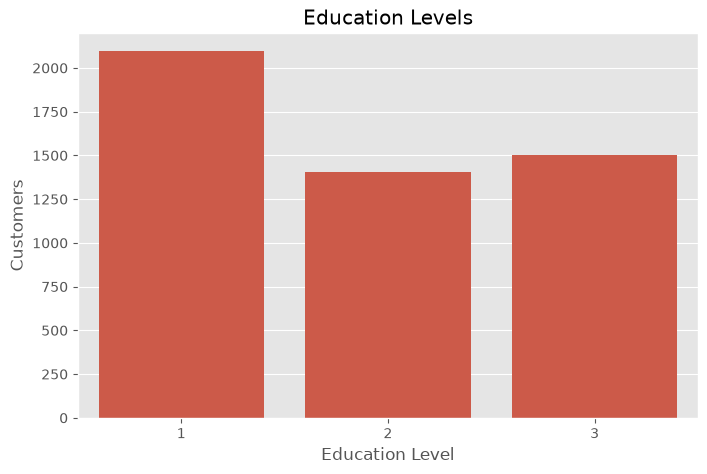

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Education"
)

plt.title("Education Levels")
plt.xlabel("Education Level")
plt.ylabel("Customers")

plt.show()

## Education Levels

The **Education** variable classifies customers according to their highest level of education:

- **1 = Undergraduate**
- **2 = Graduate**
- **3 = Advanced / Professional**

Education level is an important demographic variable because it often influences earning potential, financial literacy, and banking behaviour. Customers with higher levels of education may have greater income, higher borrowing capacity, and increased demand for financial products such as personal loans.

### Interpretation

The chart shows the distribution of customers across the three education categories.

By understanding the composition of the customer base, the bank can identify which educational groups represent the largest market segment. Comparing education levels with other variables, such as income and personal loan acceptance, can also reveal whether education influences customers' likelihood of purchasing banking products. These insights support more targeted marketing campaigns and customer segmentation strategies.

# Chart 5: Family Size

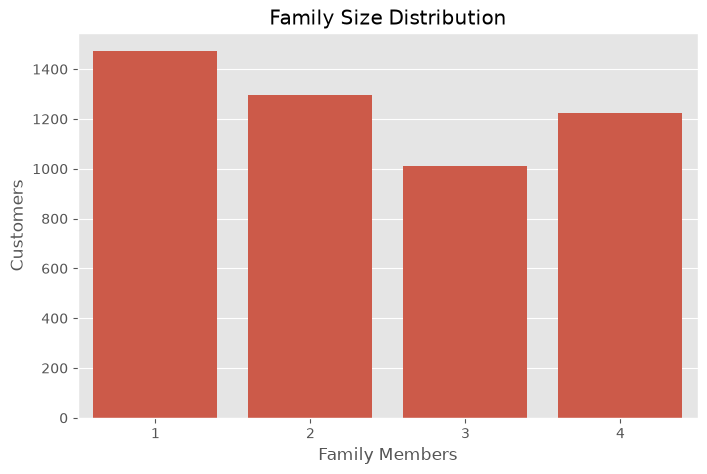

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Family"
)

plt.title("Family Size Distribution")
plt.xlabel("Family Members")
plt.ylabel("Customers")

plt.show()

### Interpretation

This chart illustrates the distribution of customers based on the number of family members in each household.

Family size can influence financial needs, spending patterns, and borrowing behaviour. Larger families may require higher household income and may have a greater demand for financial products such as personal loans, mortgages, or education financing.

The distribution also helps the bank identify the most common household sizes among its customers. These insights can be used to tailor financial products and marketing campaigns to meet the needs of different family segments.

# Correlation Analysis

Correlation analysis measures the strength and direction of relationships between numerical variables.

Understanding these relationships helps identify the factors that may influence customer behaviour, particularly personal loan acceptance. Variables with stronger correlations can provide valuable insights for marketing strategies and lending decisions.

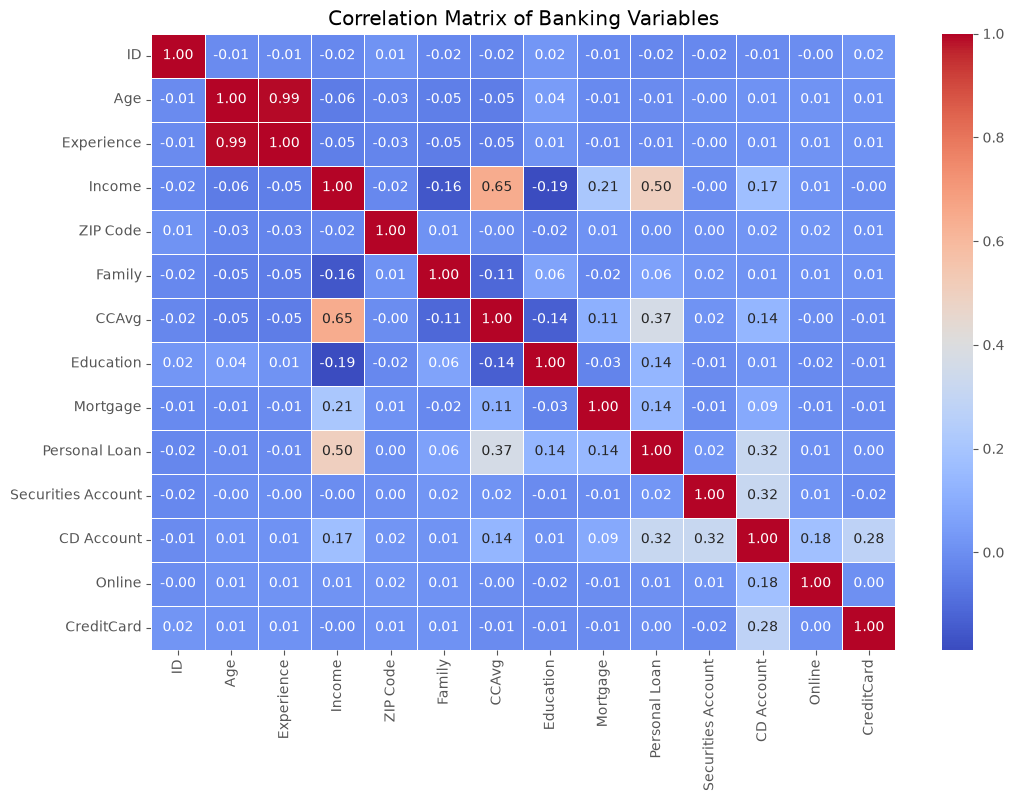

In [13]:
plt.figure(figsize=(12,8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Banking Variables")

plt.show()

### Interpretation

The correlation matrix highlights the relationships between the numerical variables in the dataset.

Positive correlation values indicate that two variables tend to increase together, while negative values indicate an inverse relationship. Variables with correlation values close to zero have little or no linear relationship.

Particular attention should be paid to variables that show stronger relationships with **Personal Loan**, as these may be important predictors of customer loan acceptance and useful features for business intelligence reporting.

## Income vs Personal Loan

One of the most important questions for the bank is:
Do higher-income customers accept personal loans more often?

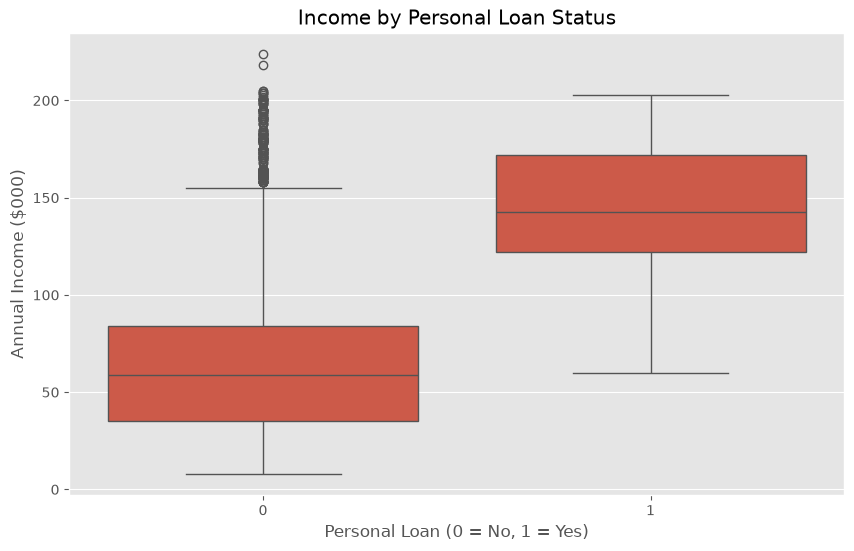

In [14]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Personal Loan",
    y="Income"
)

plt.title("Income by Personal Loan Status")
plt.xlabel("Personal Loan (0 = No, 1 = Yes)")
plt.ylabel("Annual Income ($000)")

plt.show()

### Interpretation

The box plot compares the income distribution of customers who accepted a personal loan with those who did not.

If customers who accepted loans generally have higher incomes, this suggests that income is an important factor influencing loan acceptance. Such insights can help the bank identify high-value customer segments for targeted marketing campaigns and product recommendations.

# Mortgage by Personal Loan

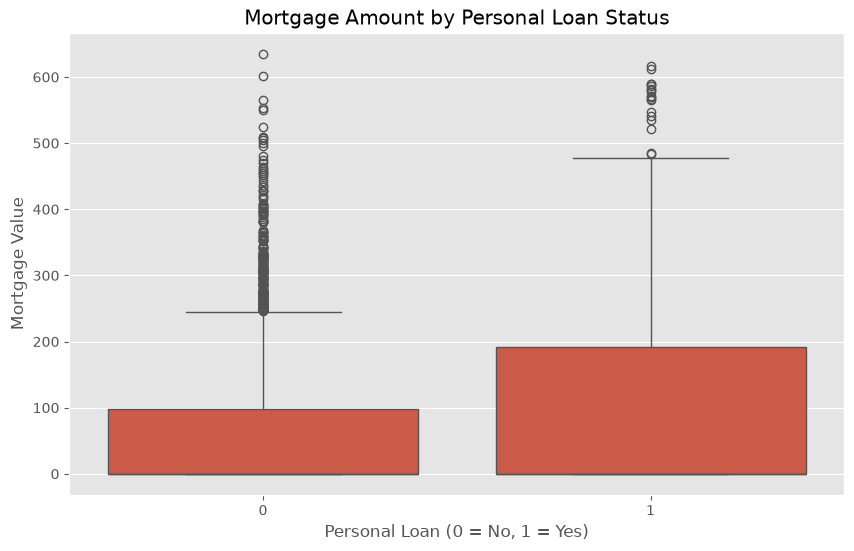

In [15]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Personal Loan",
    y="Mortgage"
)

plt.title("Mortgage Amount by Personal Loan Status")
plt.xlabel("Personal Loan (0 = No, 1 = Yes)")
plt.ylabel("Mortgage Value")

plt.show()

### Interpretation

This visualization compares mortgage values between customers who accepted a personal loan and those who did not.

Mortgage ownership may indicate a customer's financial commitments and borrowing capacity. Identifying differences between these groups helps the bank understand whether existing debt influences the likelihood of accepting additional financial products.

# Key Performance Indicators (KPIs)

Key Performance Indicators (KPIs) provide a high-level summary of the bank's customer portfolio and are commonly displayed on executive dashboards.

These metrics help stakeholders quickly assess customer demographics, financial characteristics, and product adoption rates.

In [16]:
# ===============================
# Banking KPIs
# ===============================

total_customers = len(df)
average_income = df["Income"].mean()
average_age = df["Age"].mean()
average_ccavg = df["CCAvg"].mean()
average_mortgage = df["Mortgage"].mean()

loan_acceptance_rate = (df["Personal Loan"].mean()) * 100
online_banking_rate = (df["Online"].mean()) * 100
credit_card_rate = (df["CreditCard"].mean()) * 100
cd_account_rate = (df["CD Account"].mean()) * 100
securities_rate = (df["Securities Account"].mean()) * 100

print("="*50)
print("BANKING KPI SUMMARY")
print("="*50)

print(f"Total Customers: {total_customers:,}")
print(f"Average Age: {average_age:.1f} years")
print(f"Average Income: ${average_income:.2f}K")
print(f"Average Credit Card Spending: ${average_ccavg:.2f}K")
print(f"Average Mortgage: ${average_mortgage:.2f}K")

print()

print(f"Loan Acceptance Rate: {loan_acceptance_rate:.2f}%")
print(f"Online Banking Usage: {online_banking_rate:.2f}%")
print(f"Credit Card Holders: {credit_card_rate:.2f}%")
print(f"CD Account Holders: {cd_account_rate:.2f}%")
print(f"Securities Account Holders: {securities_rate:.2f}%")

BANKING KPI SUMMARY
Total Customers: 5,000
Average Age: 45.3 years
Average Income: $73.77K
Average Credit Card Spending: $1.94K
Average Mortgage: $56.50K

Loan Acceptance Rate: 9.60%
Online Banking Usage: 59.68%
Credit Card Holders: 29.40%
CD Account Holders: 6.04%
Securities Account Holders: 10.44%


### Interpretation

The KPI summary provides an executive overview of the customer portfolio.

- **Customer Demographics:** The average age and total customer count describe the overall customer base.
- **Financial Profile:** Average income, mortgage values, and monthly credit card spending indicate the customers' financial capacity.
- **Product Adoption:** Loan acceptance, online banking usage, credit card ownership, CD accounts, and securities accounts show the adoption of banking products and services.

These KPIs can be displayed as dashboard cards in Power BI, enabling managers to monitor customer behaviour and identify opportunities for cross-selling financial products.

# Product Adoption Analysis

This section examines how widely customers use different banking products.

In [ ]:
products = {
    "Personal Loan": df["Personal Loan"].sum(),
    "Credit Card": df["CreditCard"].sum(),
    "Online Banking": df["Online"].sum(),
    "CD Account": df["CD Account"].sum(),
    "Securities Account": df["Securities Account"].sum()
}

plt.figure(figsize=(10,6))

plt.bar(products.keys(), products.values())

plt.title("Banking Product Adoption")
plt.xlabel("Banking Product")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

### Interpretation

The chart compares customer adoption across the bank's major products and services.

Products with higher adoption rates represent established services, while those with lower adoption rates may indicate opportunities for targeted marketing or customer education. Understanding product usage helps the bank identify cross-selling opportunities and improve customer engagement.

# Income Analysis by Education Level

Education often plays a significant role in an individual's earning potential. In this section, we compare the income distributions of customers across different education levels.

Understanding these differences can help the bank identify customer segments with higher purchasing power and tailor financial products accordingly.

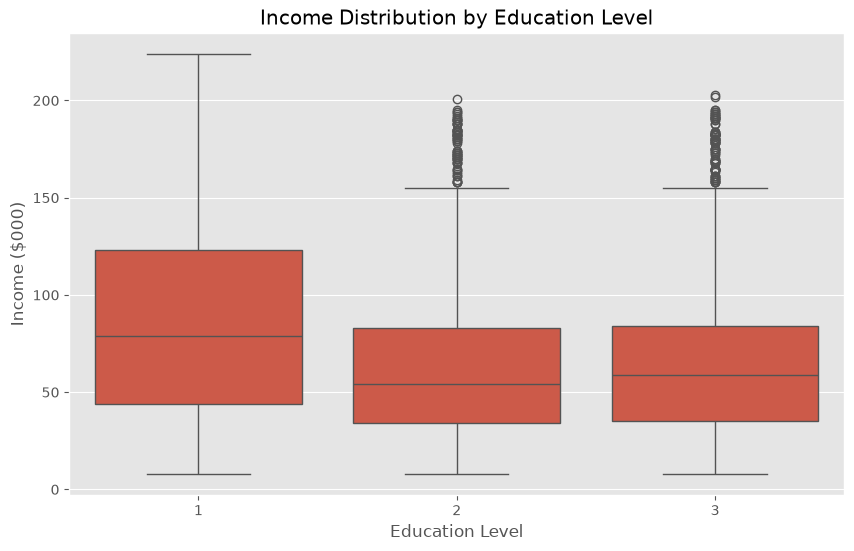

In [17]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Education",
    y="Income"
)

plt.title("Income Distribution by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Income ($000)")

plt.show()

## Interpretation

The box plot compares annual income across different education levels.

Differences in median income and income spread can indicate whether higher educational attainment is associated with greater earning potential. These insights help the bank understand which customer groups may have a higher capacity for borrowing and investing in financial products.

## Loan Acceptance by Education Level

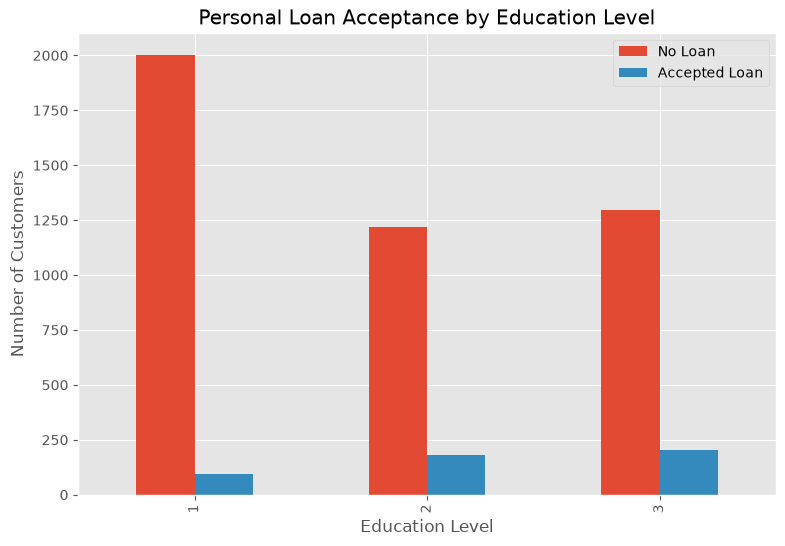

In [18]:
loan_by_education = pd.crosstab(
    df["Education"],
    df["Personal Loan"]
)

loan_by_education.plot(
    kind="bar",
    figsize=(9,6)
)

plt.title("Personal Loan Acceptance by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Number of Customers")

plt.legend(["No Loan","Accepted Loan"])

plt.show()

### Interpretation

This chart compares the number of customers who accepted and declined a personal loan within each education level.

By examining loan acceptance across educational groups, the bank can identify which segments respond most positively to loan offerings. These insights can inform targeted marketing strategies and personalized financial products.

## Family Size vs Loan Acceptance

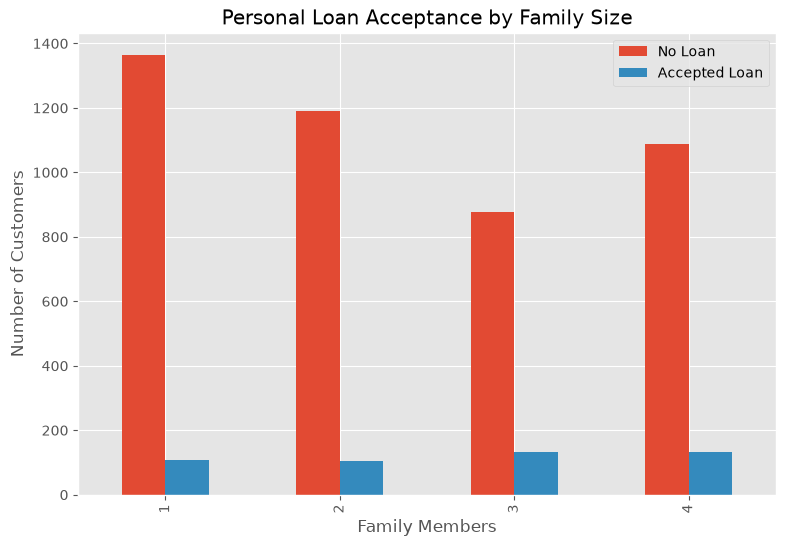

In [19]:
family_loans = pd.crosstab(
    df["Family"],
    df["Personal Loan"]
)

family_loans.plot(
    kind="bar",
    figsize=(9,6)
)

plt.title("Personal Loan Acceptance by Family Size")
plt.xlabel("Family Members")
plt.ylabel("Number of Customers")

plt.legend(["No Loan","Accepted Loan"])

plt.show()

### Interpretation

Family size may influence financial responsibilities and borrowing needs.

The chart illustrates how loan acceptance varies across different household sizes, helping the bank understand whether larger families are more likely to require additional financial support through personal loans.

# Relationship Between Age and Income

This analysis examines whether there is a relationship between customer age and annual income.

Understanding this relationship can help identify customer segments with greater financial capacity and support strategic product recommendations.

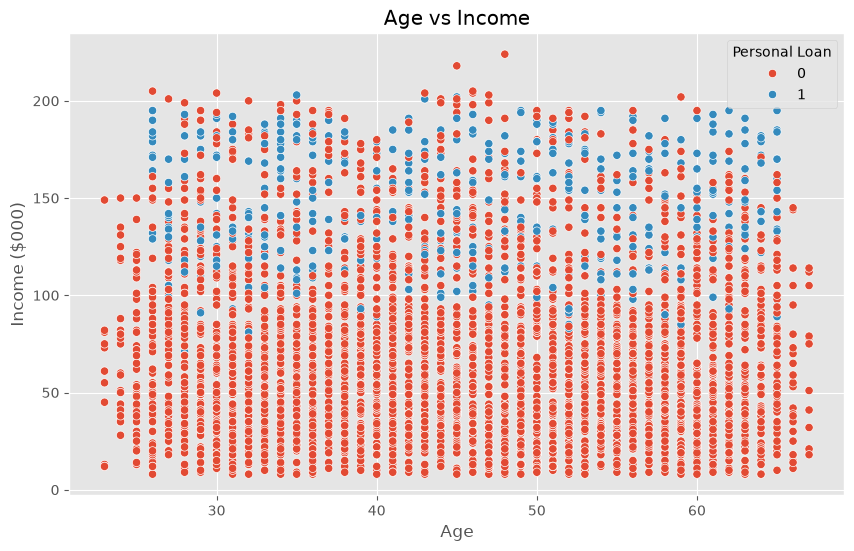

In [20]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Income",
    hue="Personal Loan"
)

plt.title("Age vs Income")
plt.xlabel("Age")
plt.ylabel("Income ($000)")

plt.show()

### Interpretation

The scatter plot visualizes the relationship between age and annual income while distinguishing customers based on personal loan acceptance.

Clusters of customers may emerge, revealing demographic patterns associated with higher income levels and loan uptake. Such insights can help the bank identify customer profiles that are more likely to respond to loan offers.

# Key Business Insights

Based on the exploratory data analysis, several important insights were identified:

### 1. Income Influences Loan Acceptance
Customers with higher annual incomes are more likely to accept personal loan offers, suggesting that income is a strong indicator of borrowing capacity.

### 2. Education Impacts Financial Behaviour
Customers with graduate and advanced/professional education generally exhibit higher income levels and appear more responsive to loan products.

### 3. Household Size Affects Loan Demand
Customers with larger families tend to have greater financial responsibilities, which may contribute to a higher likelihood of accepting personal loans.

### 4. Mortgage Ownership Varies Across Customers
Mortgage values differ considerably among customers, indicating varying levels of existing financial commitments.

### 5. Digital Banking Adoption is High
A large proportion of customers use online banking services, demonstrating strong adoption of digital banking channels.

### 6. Cross-Selling Opportunities Exist
Customers who already use products such as credit cards, securities accounts, and CD accounts may represent ideal candidates for additional financial products.

### 7. Customer Segmentation Can Improve Marketing
The combination of demographic, financial, and banking variables enables the bank to identify customer segments for more targeted marketing campaigns.

# Business Recommendations

Based on the analysis, the following recommendations are proposed:

- Target higher-income customers with personalised personal loan offers.
- Promote premium financial products to customers with advanced education and higher earning potential.
- Develop marketing campaigns specifically for larger households that may require additional financial support.
- Increase cross-selling initiatives by recommending loans to customers who already hold multiple banking products.
- Expand digital banking services to further improve customer engagement and convenience.
- Continue monitoring customer financial profiles to identify changing borrowing needs and improve risk management.

# SQL Queries for Business Intelligence

The following SQL queries can be used to support dashboard reporting and business analysis.

In [22]:

SELECT COUNT(*) AS Total_Customers
FROM Banking_Customers;

-- Average income
SELECT AVG(Income) AS Average_Income
FROM Banking_Customers;

-- Loan acceptance rate
SELECT
    AVG([Personal Loan]) * 100 AS Loan_Acceptance_Rate
FROM Banking_Customers;

-- Average income by education
SELECT
    Education,
    AVG(Income) AS Average_Income
FROM Banking_Customers
GROUP BY Education;

-- Customers by family size
SELECT
    Family,
    COUNT(*) AS Customers
FROM Banking_Customers
GROUP BY Family;

-- Online banking usage
SELECT
    Online,
    COUNT(*) AS Customers
FROM Banking_Customers
GROUP BY Online;

-- Credit card ownership
SELECT
    CreditCard,
    COUNT(*) AS Customers
FROM Banking_Customers
GROUP BY CreditCard;

SyntaxError: invalid syntax (2905760304.py, line 1)